# Citi Bike (NYC) — Trực quan hóa

Dữ liệu: `dataclean/`. Chạy **Run All** sau khi đã clean.


In [51]:
import importlib
import os
import sys
from pathlib import Path

current_dir = os.getcwd()
if current_dir.endswith(("notebooks", "1.statistic", "2.visualize")):
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.visualize_plots as visualize_plots
import src.station_maps as station_maps
importlib.reload(visualize_plots)
importlib.reload(station_maps)

from src.visualize_plots import (
    plot_user_type_pie,
    plot_bike_type_pie_by_user,
    plot_duration_by_bike_type,
    plot_duration_by_bike_type_pct,
    plot_duration_box_by_bike,
    plot_hourly_demand_by_bike_type_count,
    plot_hourly_demand_by_bike_type,
    plot_duration_by_user_group,
    plot_duration_by_user_group_pct,
    plot_duration_box_by_user,
    plot_hourly_demand_by_user_count,
    plot_hourly_demand_by_user,
    plot_monthly_demand_by_user_count,
    plot_monthly_demand_by_user,
    plot_weekday_demand_by_bike_type,
    plot_weekday_demand_by_user,
    plot_weekly_usage_heatmap,
    plot_weekly_usage_heatmap_by_bike_type,
    plot_weekly_usage_heatmap_user_bike_grid,
    plot_monthly_usage_heatmaps,
    plot_monthly_usage_heatmaps_by_bike_type,
    plot_monthly_usage_heatmaps_member_by_bike,
    plot_monthly_usage_heatmaps_casual_by_bike,
)
from src.station_maps import plot_station_map

CLEAN_FILE = "citibike_nyc_cleaned.parquet"
SYSTEM_NAME = "Citi Bike (NYC)"
DATA_PATH = Path(project_root) / "dataclean" / CLEAN_FILE

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Chưa có {DATA_PATH}. Chạy scripts/run_clean_all.py trước.")


## Khối 0 · Tổng quan cơ cấu


### 1. Tỷ lệ member vs casual

Biểu đồ tròn toàn bộ chuyến trong kỳ phân tích.


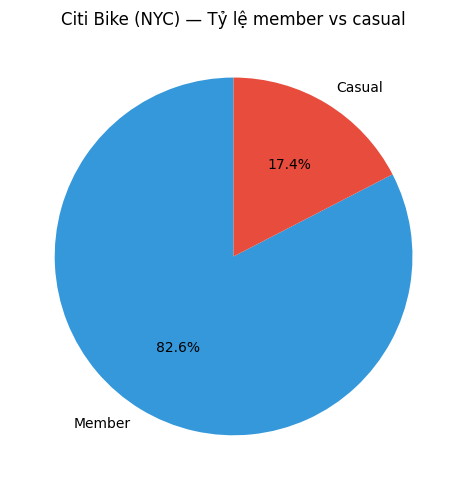

In [52]:
plot_user_type_pie(DATA_PATH, SYSTEM_NAME)


### 2. Tỷ lệ loại xe theo nhóm người dùng

Hai pie nhỏ: member và casual, mỗi pie tách classic / e-bike.


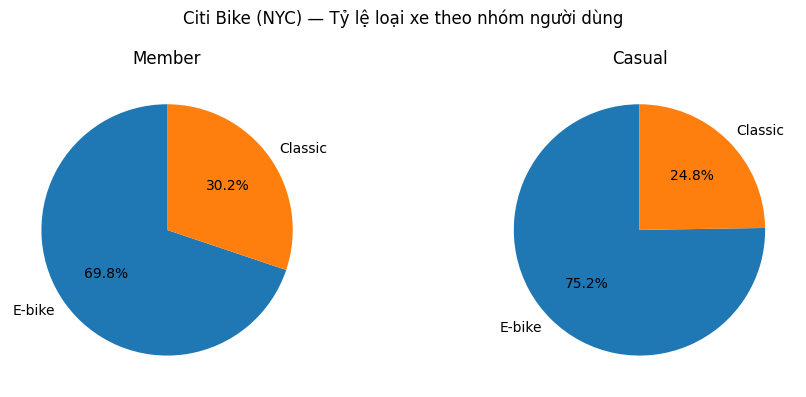

In [53]:
plot_bike_type_pie_by_user(DATA_PATH, SYSTEM_NAME)


## Khối A · Classic vs e-bike


### 3. Thời lượng — số chuyến (0–120 phút)

Histogram chồng theo số chuyến thực tế.


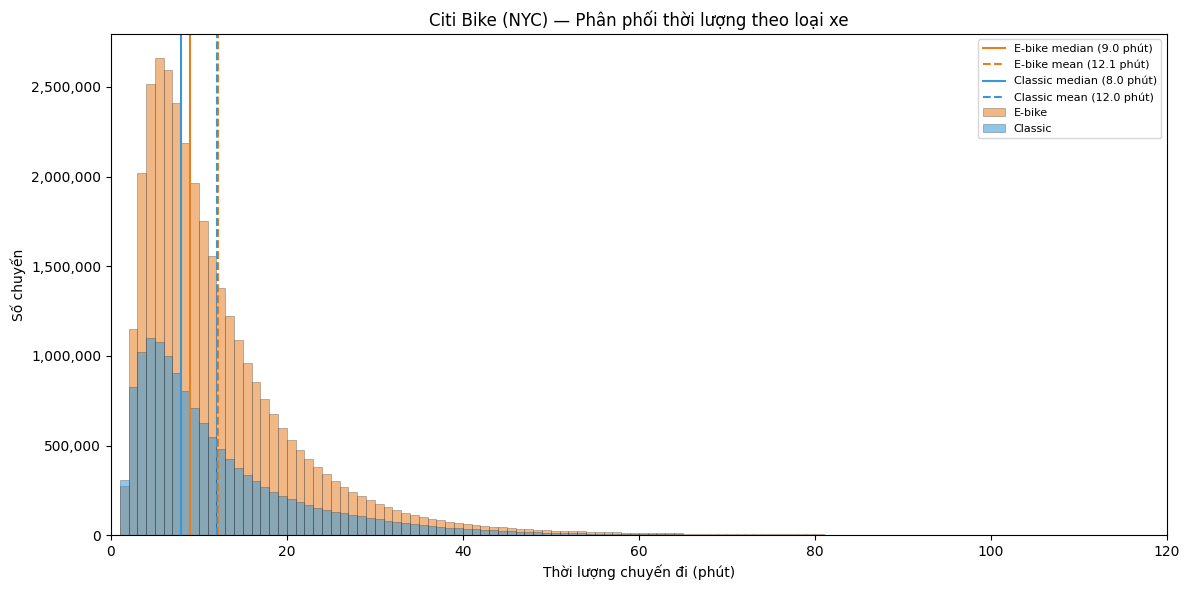

In [54]:
plot_duration_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 4. Thời lượng — % trong từng loại xe

Mỗi loại xe chuẩn hóa 100% — so sánh hình dạng phân phối.


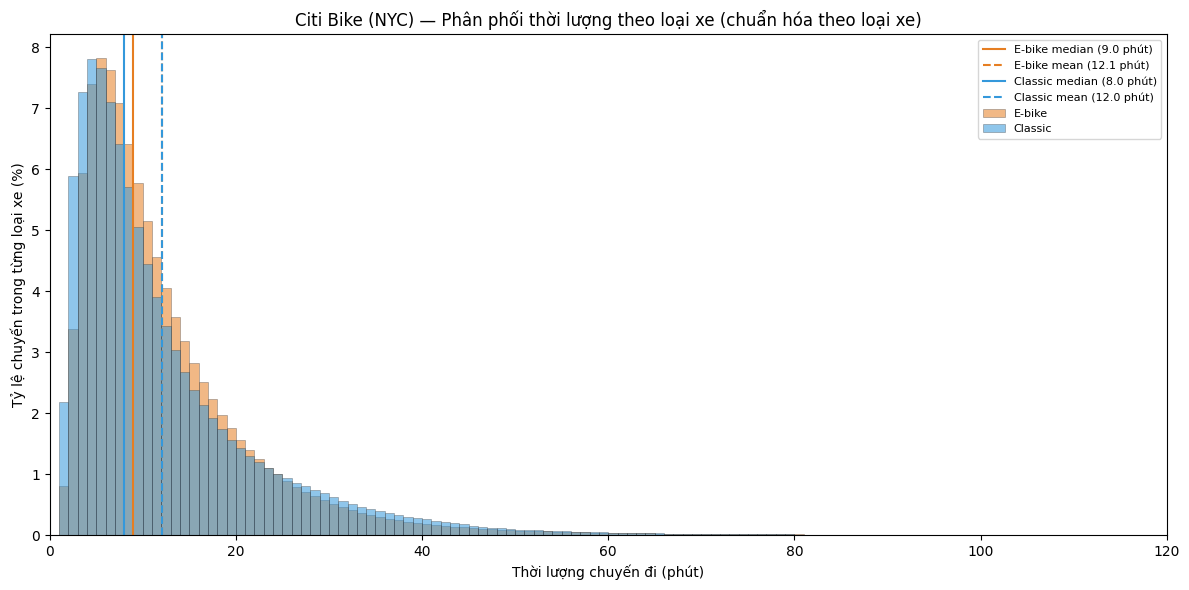

In [55]:
plot_duration_by_bike_type_pct(DATA_PATH, SYSTEM_NAME)


### Box plot — classic vs e-bike (0–120 phút)

Tóm tắt Q1, median, Q3 và whisker Tukey — bổ sung cho histogram.


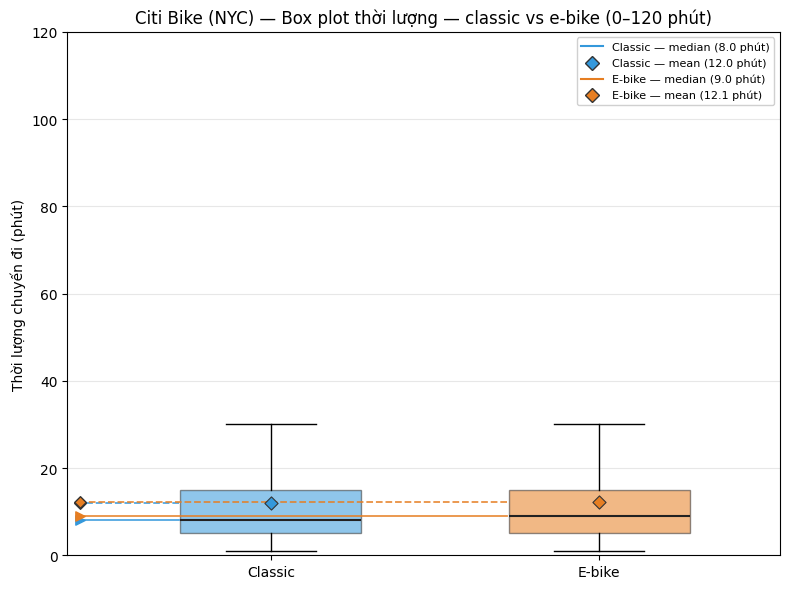

In [56]:
plot_duration_box_by_bike(DATA_PATH, SYSTEM_NAME)


### 5. Nhu cầu theo giờ — số chuyến

Trục X: giờ bắt đầu (0–23). Vùng vàng/cam: cao điểm 7–9h và 16–18h.


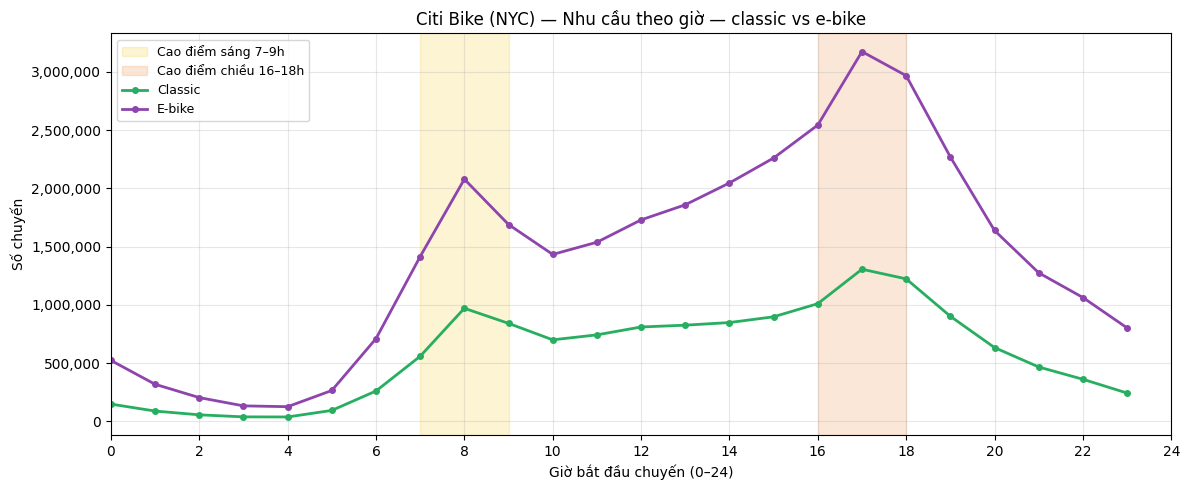

In [57]:
plot_hourly_demand_by_bike_type_count(DATA_PATH, SYSTEM_NAME)


### 6. Nhu cầu theo giờ — % trong từng loại xe

Mỗi loại xe chuẩn hóa 100% theo 24 giờ.


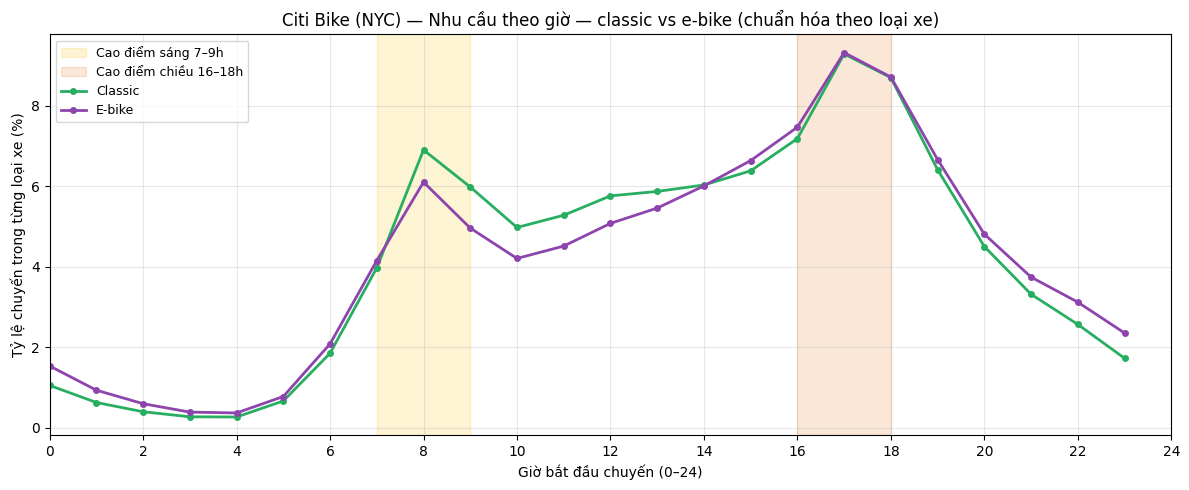

In [58]:
plot_hourly_demand_by_bike_type(DATA_PATH, SYSTEM_NAME)


## Khối B · Member vs casual


### 7. Thời lượng — số chuyến (0–120 phút)

Histogram chồng theo số chuyến thực tế.


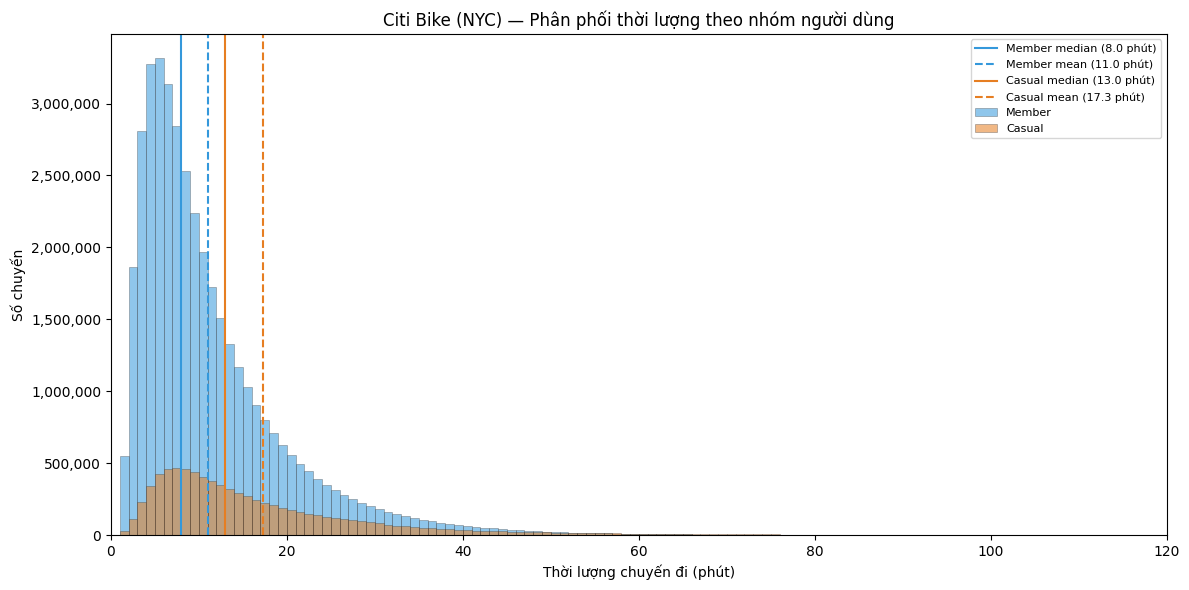

In [59]:
plot_duration_by_user_group(DATA_PATH, SYSTEM_NAME)


### 8. Thời lượng — % trong từng nhóm

Mỗi nhóm chuẩn hóa 100% — so sánh hình dạng phân phối.


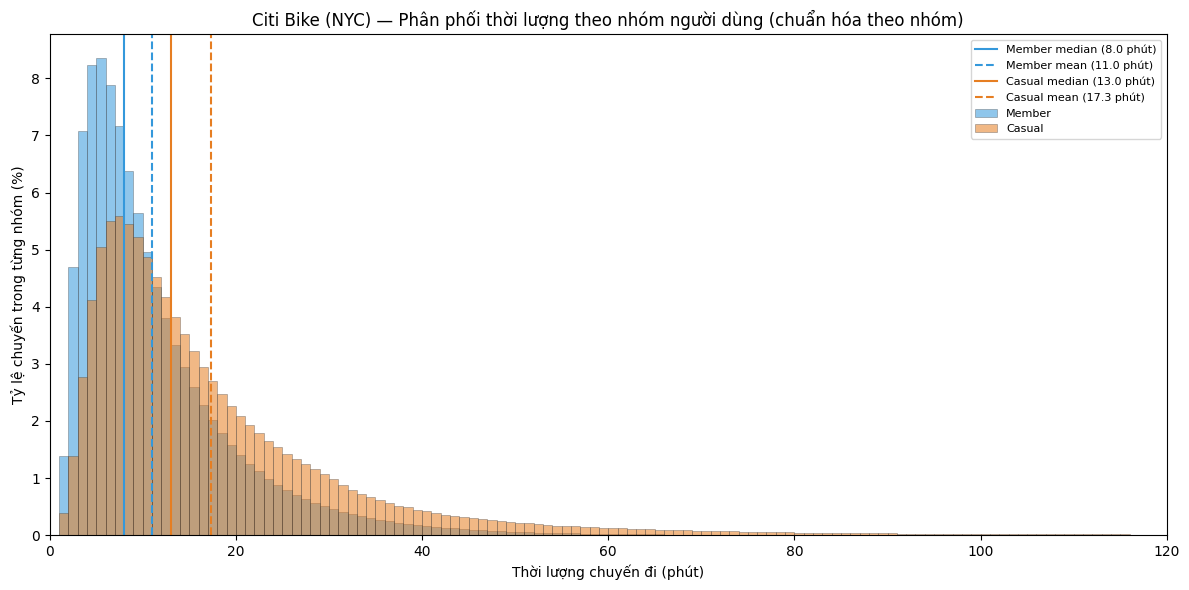

In [60]:
plot_duration_by_user_group_pct(DATA_PATH, SYSTEM_NAME)


### Box plot — member vs casual (0–120 phút)

Tóm tắt Q1, median, Q3 và whisker Tukey — bổ sung cho histogram.


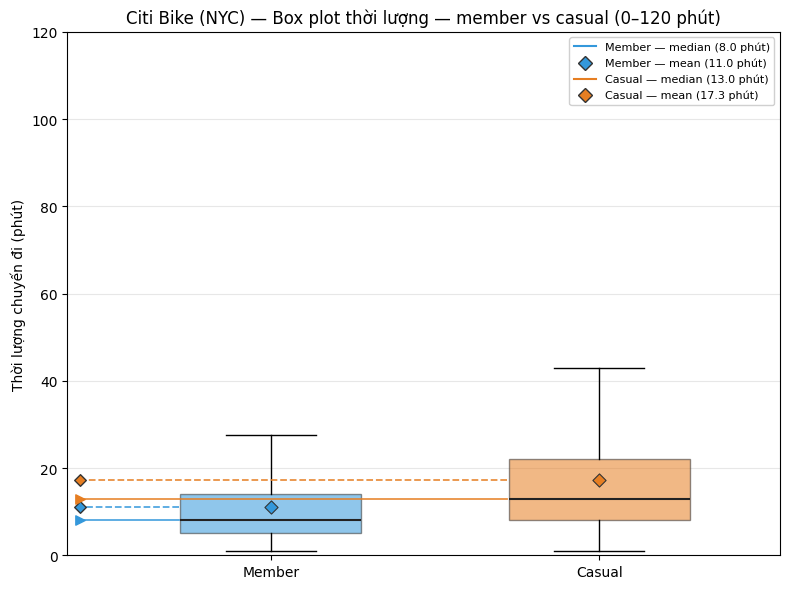

In [61]:
plot_duration_box_by_user(DATA_PATH, SYSTEM_NAME)


### 9. Nhu cầu theo giờ — số chuyến

Trục X: giờ bắt đầu (0–23).


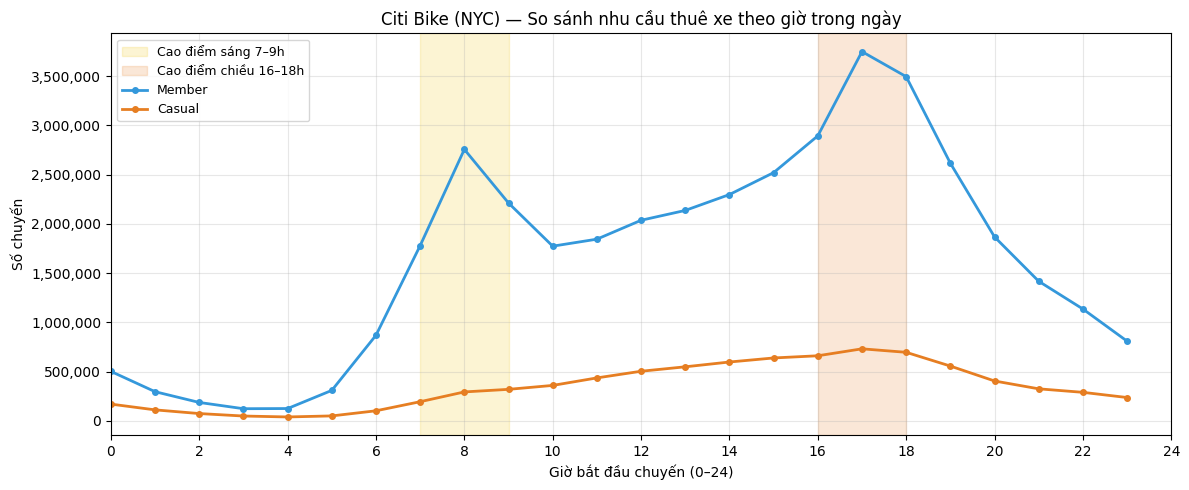

In [62]:
plot_hourly_demand_by_user_count(DATA_PATH, SYSTEM_NAME)


### 10. Nhu cầu theo giờ — % trong từng nhóm

Mỗi nhóm chuẩn hóa 100% theo 24 giờ.


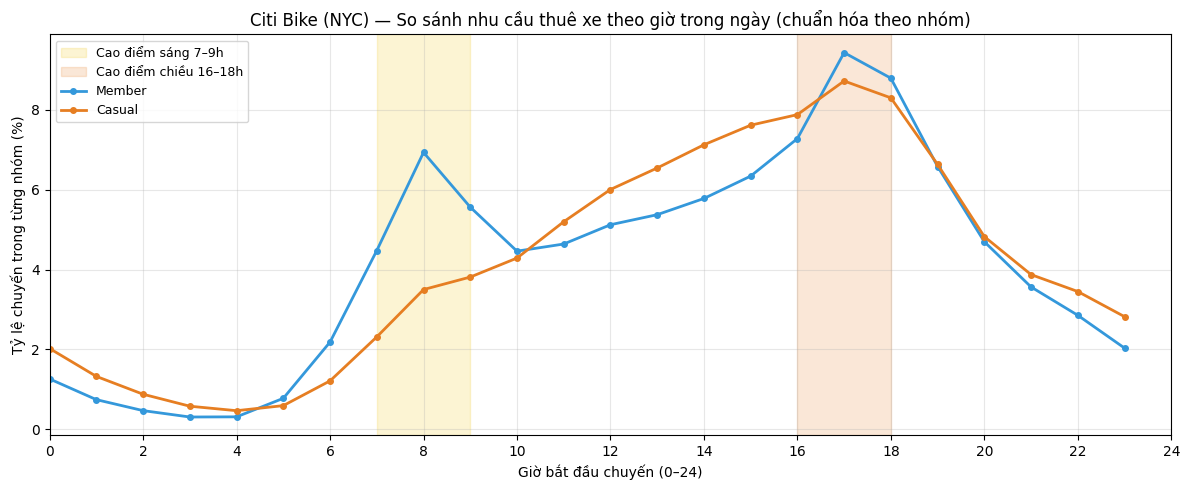

In [63]:
plot_hourly_demand_by_user(DATA_PATH, SYSTEM_NAME)


### 11. Nhu cầu theo tháng — số chuyến

Kỳ 04/2025–04/2026. Nền cam: hè (6–8); nền xanh nhạt: đông (12–2).


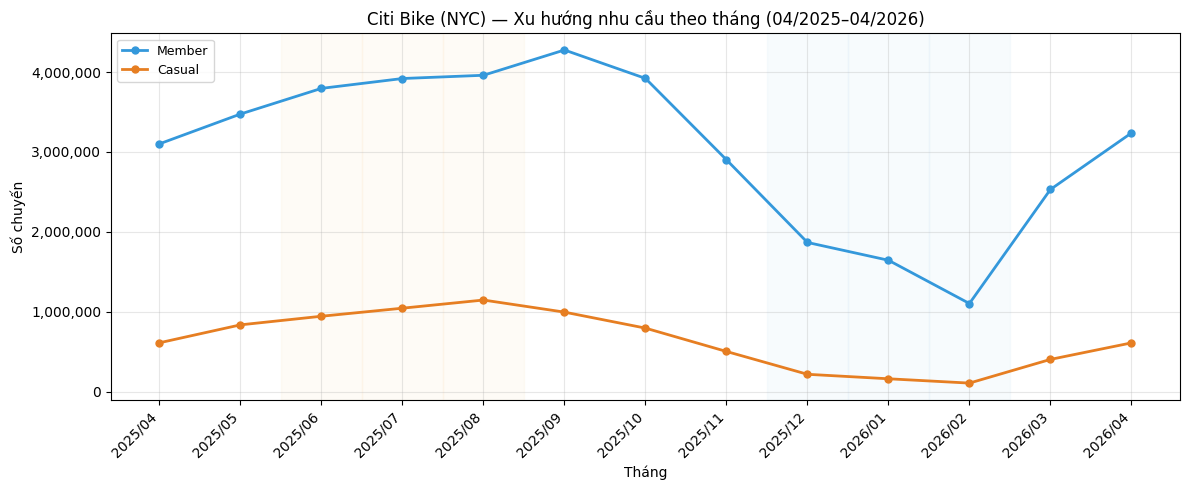

In [64]:
plot_monthly_demand_by_user_count(DATA_PATH, SYSTEM_NAME)


### 12. Nhu cầu theo tháng — % trong từng nhóm

Mỗi nhóm chuẩn hóa 100% theo 13 tháng.


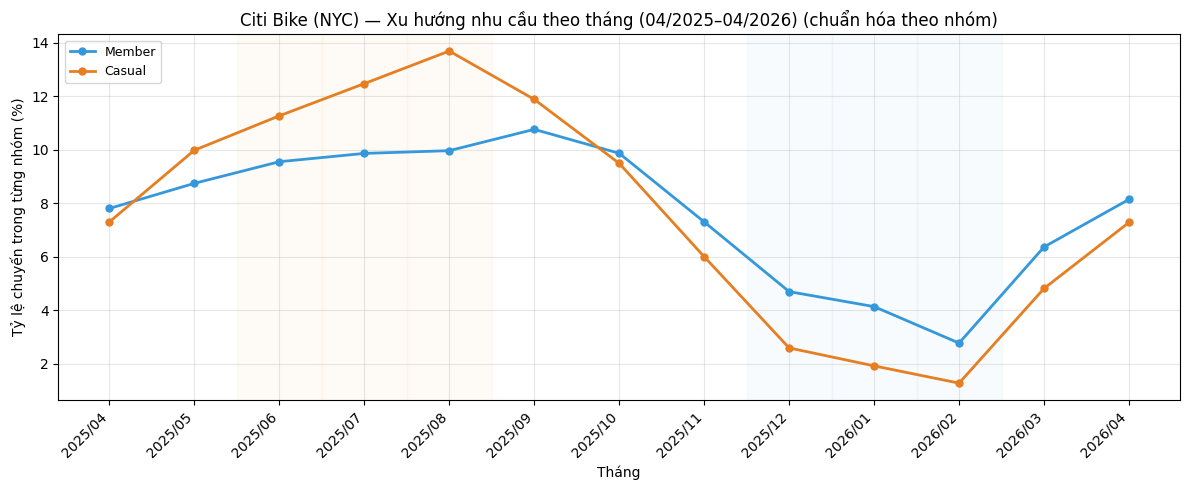

In [65]:
plot_monthly_demand_by_user(DATA_PATH, SYSTEM_NAME)


## Khối C · Ngày trong tuần (T2–CN)


### 13. Classic vs e-bike — số chuyến

Line chart 7 ngày. Vùng tím nhạt: cuối tuần (T7–CN).


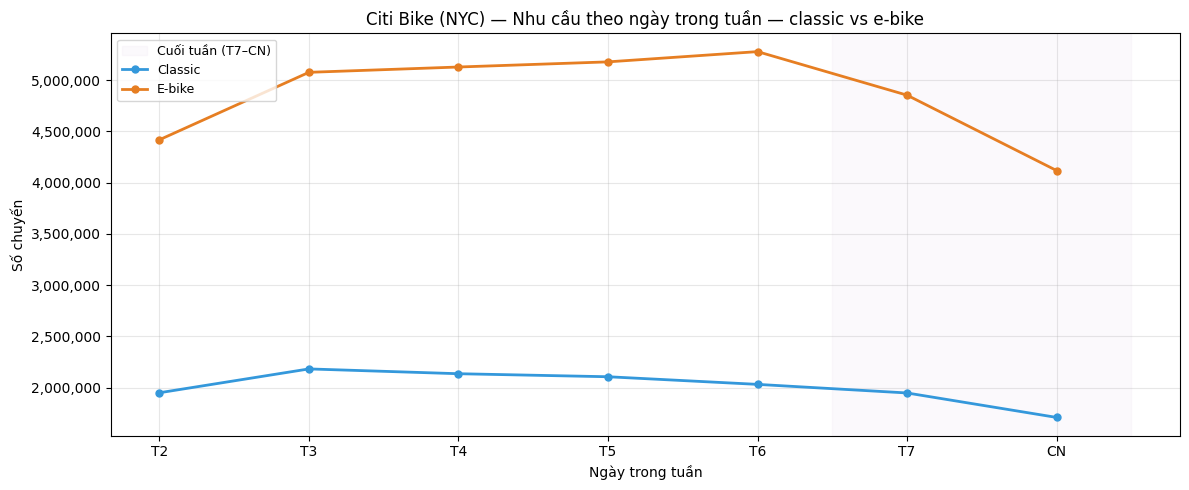

In [66]:
plot_weekday_demand_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 14. Member vs casual — số chuyến

Line chart 7 ngày, chỉ số chuyến (không chuẩn hóa %).


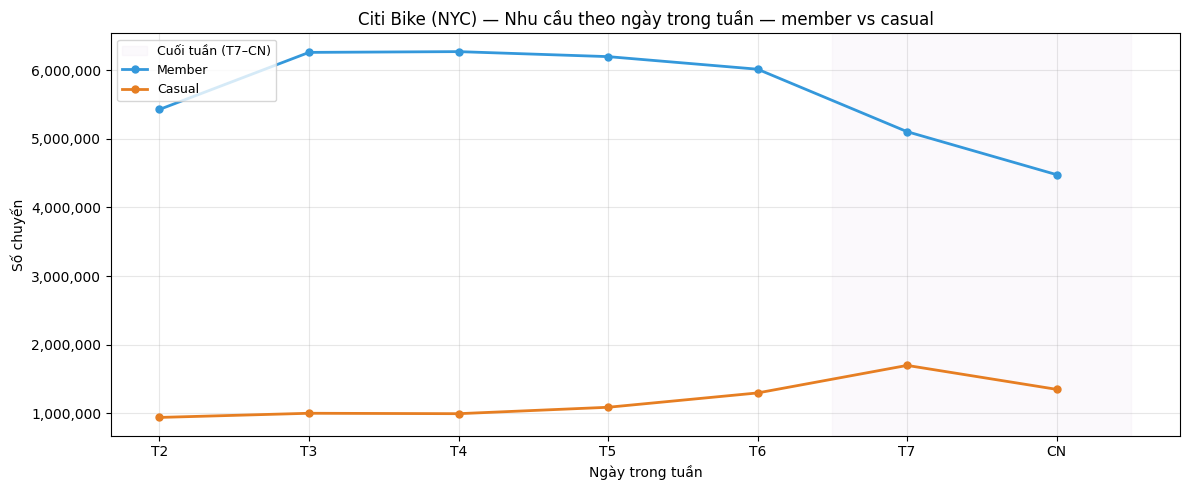

In [67]:
plot_weekday_demand_by_user(DATA_PATH, SYSTEM_NAME)


## Khối D · Heatmap giờ × ngày — toàn kỳ


### 15. Member | casual

Trục X: giờ (0–23). Trục Y: ngày (T2–CN). Mỗi panel scale màu riêng.


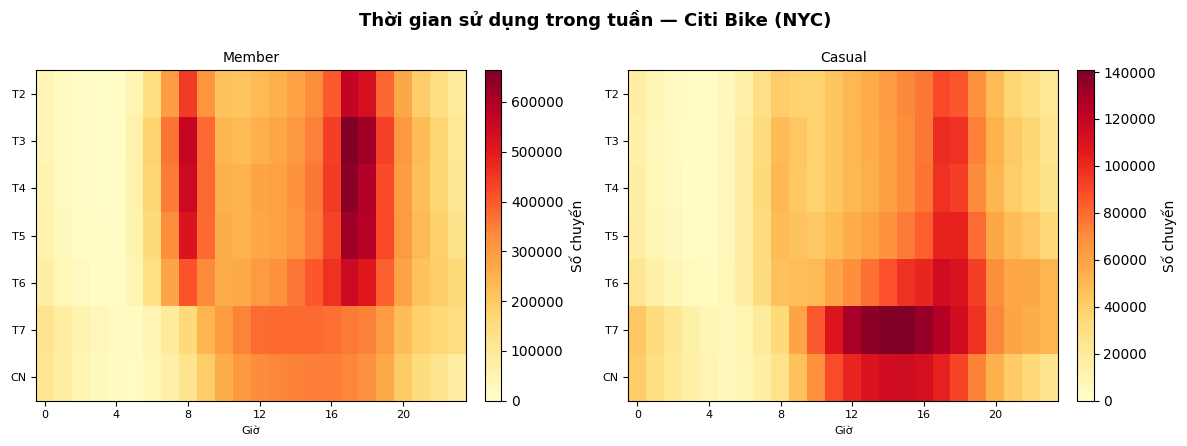

In [68]:
plot_weekly_usage_heatmap(DATA_PATH, SYSTEM_NAME)


### 16. Classic | e-bike

Cùng form với phần 15.


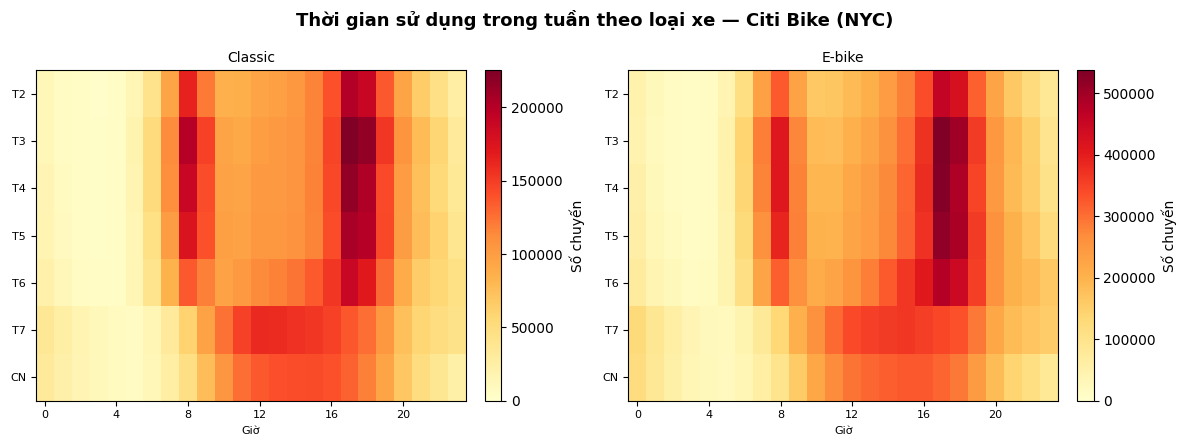

In [69]:
plot_weekly_usage_heatmap_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 17. Lưới 2×2 (người dùng × loại xe)

Member×classic, member×e-bike, casual×classic, casual×e-bike.


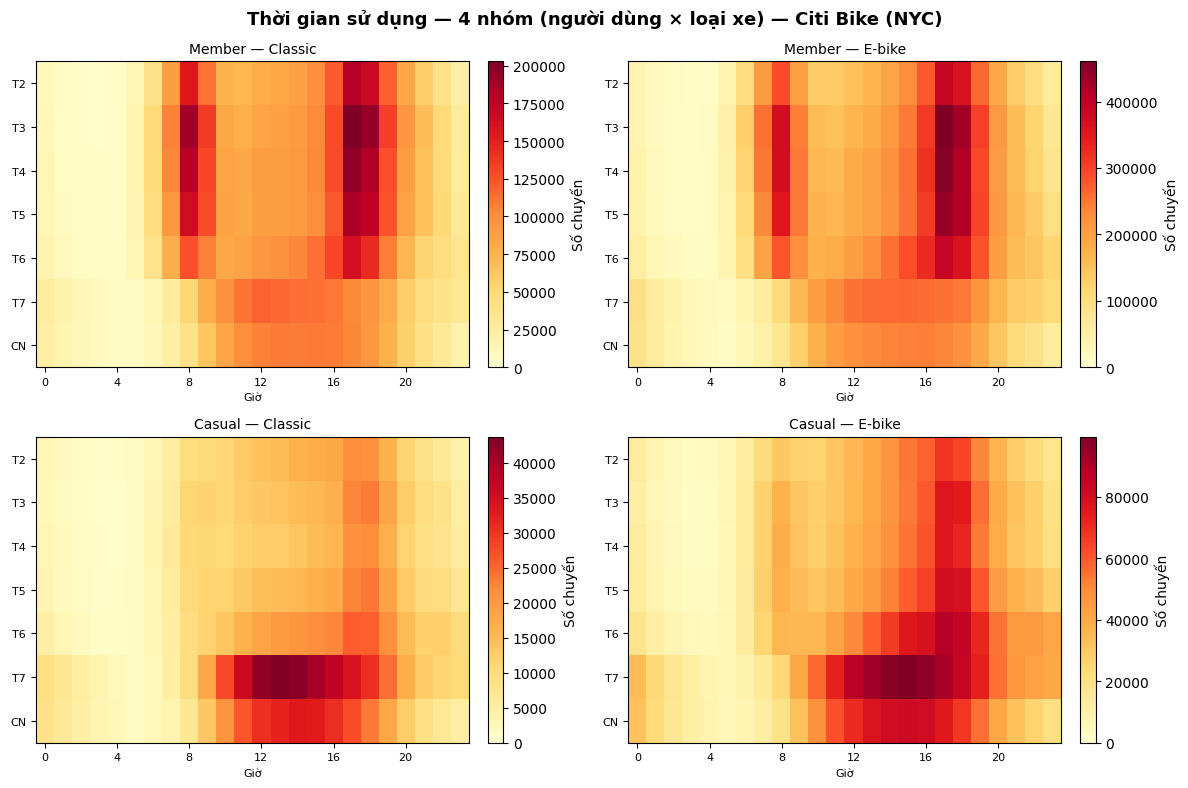

In [70]:
plot_weekly_usage_heatmap_user_bike_grid(DATA_PATH, SYSTEM_NAME)


## Khối E · Heatmap giờ × ngày — theo tháng


### 18. Member | casual

13 hàng (04/2025–04/2026), mỗi hàng 2 cột.


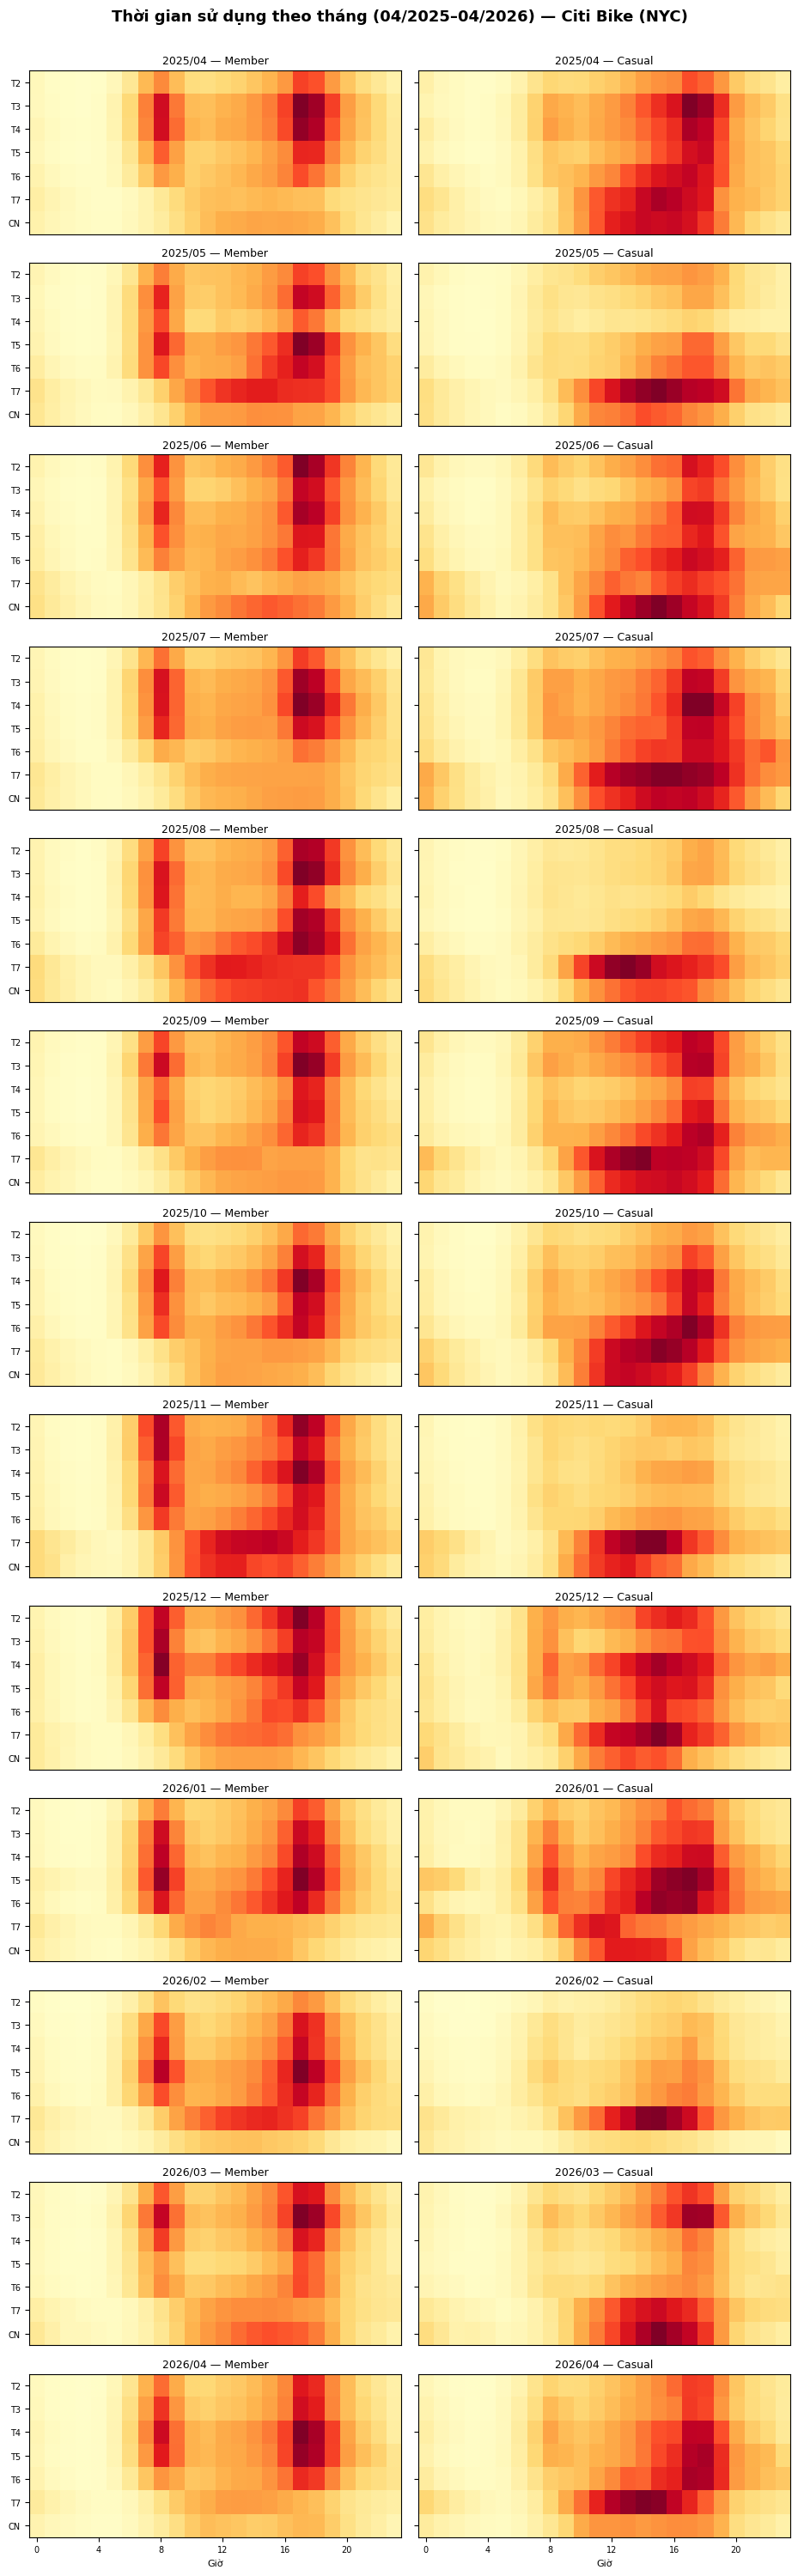

In [71]:
plot_monthly_usage_heatmaps(DATA_PATH, SYSTEM_NAME)


### 19. Classic | e-bike

13 hàng, 2 cột — cùng form với phần 16.


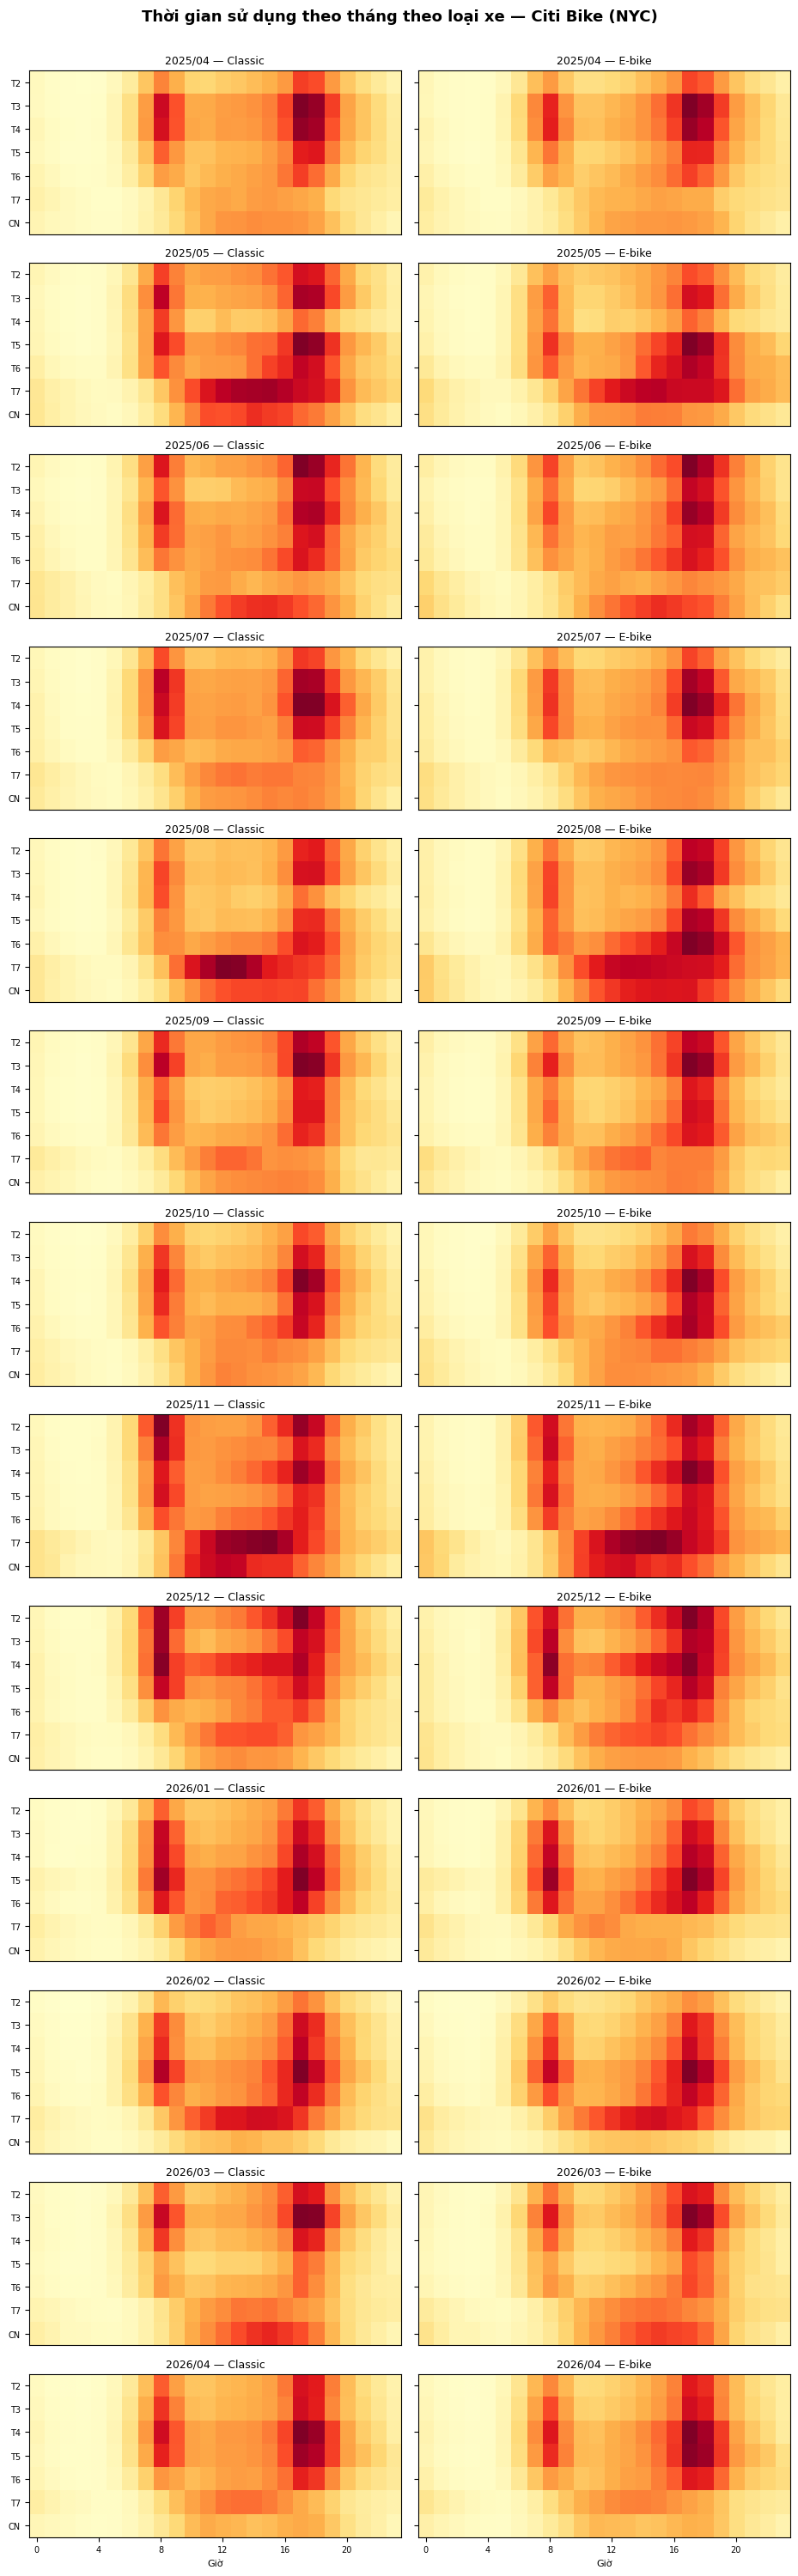

In [72]:
plot_monthly_usage_heatmaps_by_bike_type(DATA_PATH, SYSTEM_NAME)


### 20. Member — classic | e-bike

13 hàng, 2 cột — tách riêng nhóm member.


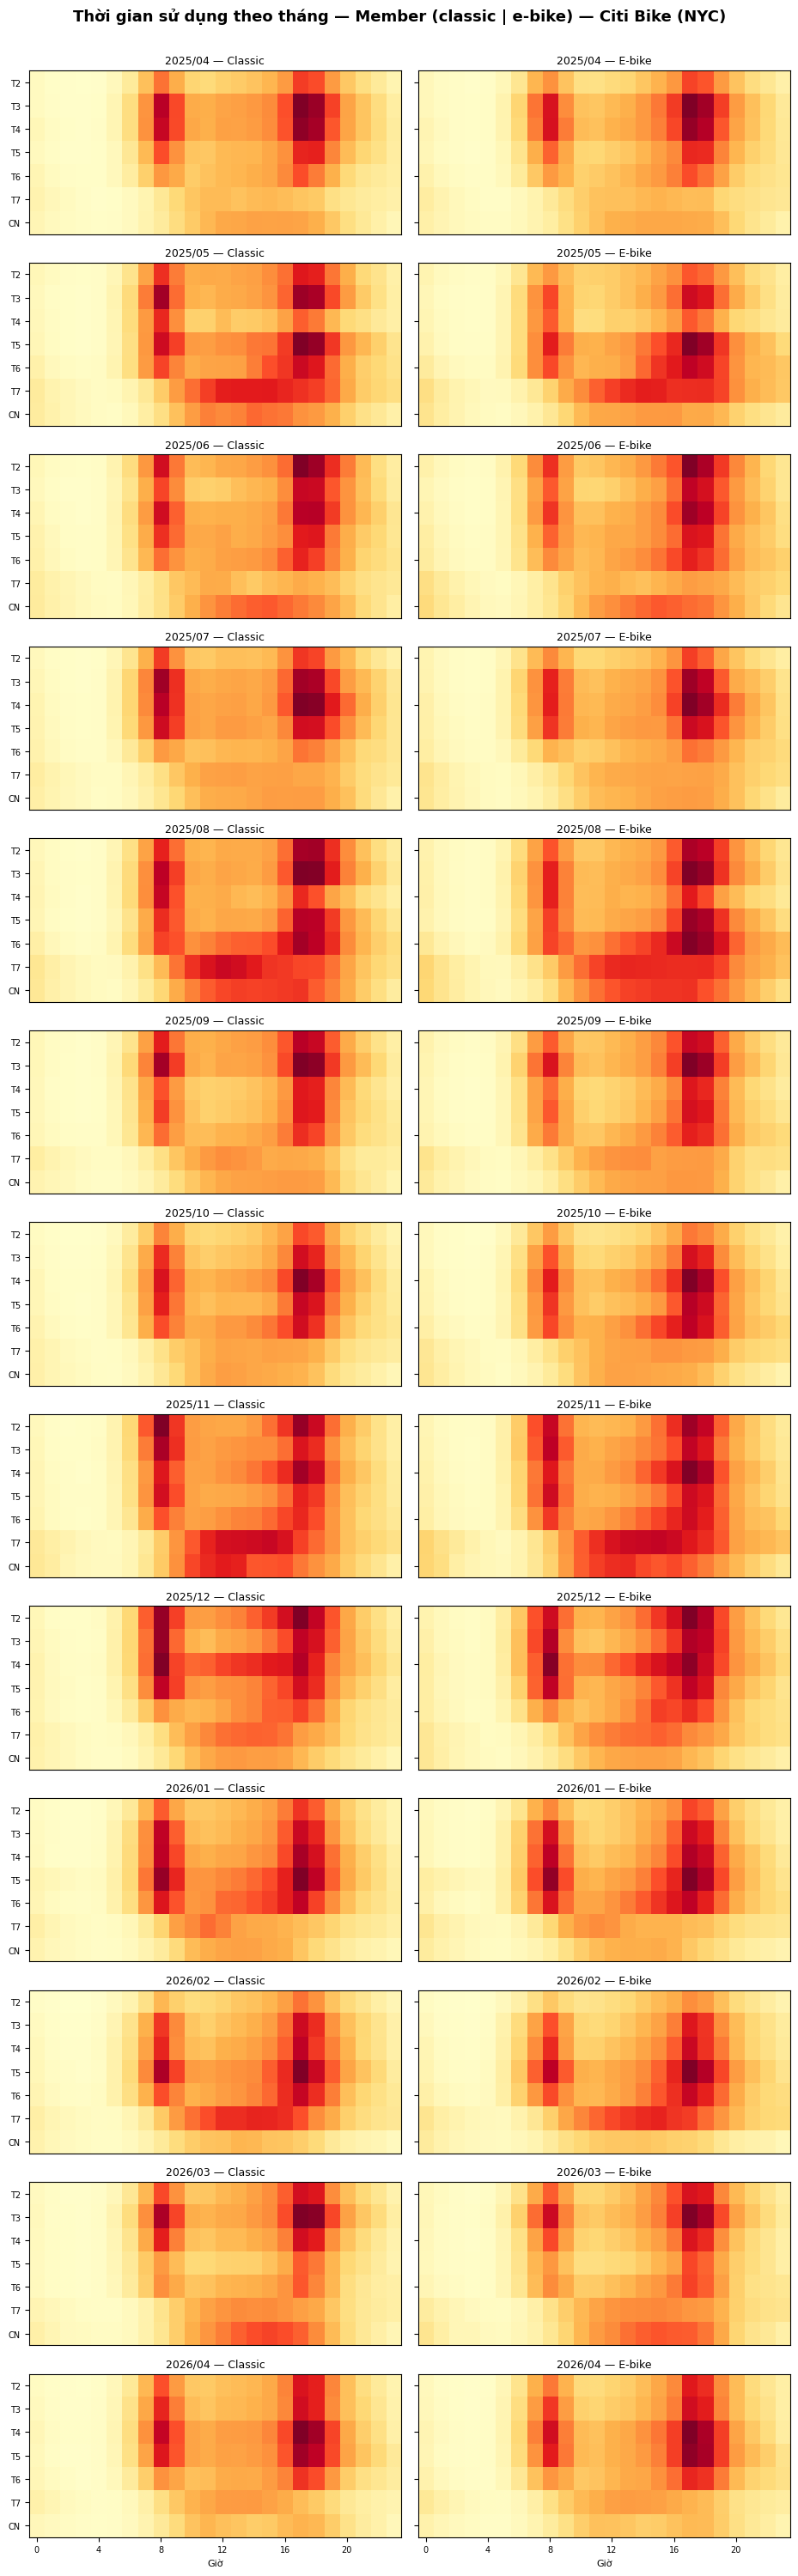

In [73]:
plot_monthly_usage_heatmaps_member_by_bike(DATA_PATH, SYSTEM_NAME)


### 21. Casual — classic | e-bike

13 hàng, 2 cột — tách riêng nhóm casual.


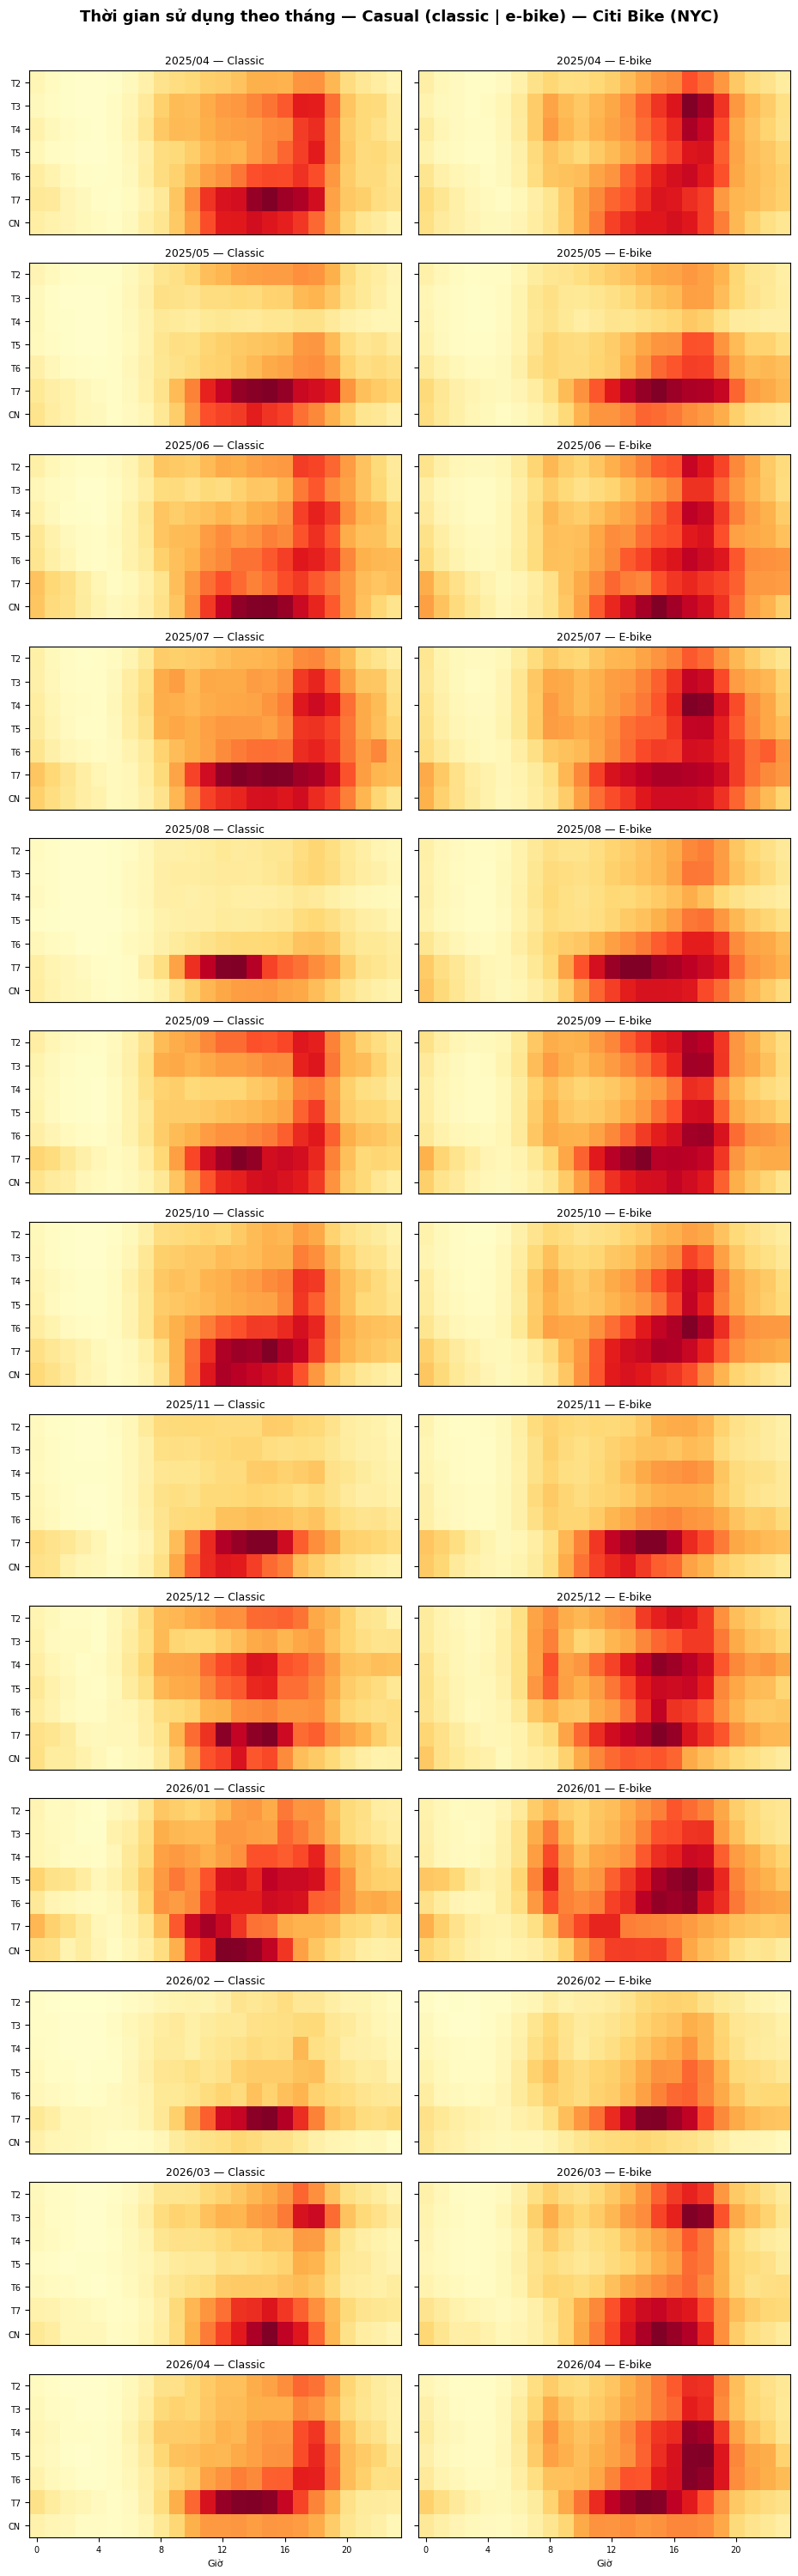

In [74]:
plot_monthly_usage_heatmaps_casual_by_bike(DATA_PATH, SYSTEM_NAME)


## Khối F · Bản đồ trạm


### Bản đồ trạm — số chuyến bắt đầu

Nền OpenStreetMap. Gom trạm theo `station_id` hoặc tọa độ làm tròn (e-bike). Kích thước chấm ∝ số chuyến; cluster khi zoom xa.


In [75]:
plot_station_map(DATA_PATH, SYSTEM_NAME)
